In [1]:
import os
import subprocess
import sys
# Configure JuliaCall to use existing Julia installation
julia_exe = subprocess.check_output(["which", "julia"]).decode().strip()
clanqs_project = "/storage/niggeni/Documents/Projects/DataMiningRBMs/Netket/CLANQS"

os.environ["JULIA"] = subprocess.check_output(["which", "julia"]).decode().strip()
os.environ["JULIA_PROJECT"] = clanqs_project
os.environ["JULIA_PYTHONCALL_EXE"] = sys.executable

# Use the CLANQS Julia project environment
os.environ["PYTHON_JULIACALL_PROJECT"] = clanqs_project

# WICHTIG: Erzwingt, dass Julia die aktuelle Python-Umgebung nutzt
print(f"Using Julia: {julia_exe}")
print(f"Julia project: {clanqs_project}")
import juliacall
from juliacall import Main as jl

Using Julia: /storage/niggeni/.juliaup/bin/julia
Julia project: /storage/niggeni/Documents/Projects/DataMiningRBMs/Netket/CLANQS


/storage/niggeni/pyenv/.venvNK/lib/python3.13/site-packages/juliacall/__init__.py:302: UserWarning: Julia was started with multiple threads but multithreading support is experimental in JuliaCall. It is recommended to restart Python with the environment variable PYTHON_JULIACALL_HANDLE_SIGNALS=yes set, otherwise you may experience segfaults or other crashes. Note however that this interferes with Python's own signal handling, so for example Ctrl-C will not raise KeyboardInterrupt. See https://juliapy.github.io/PythonCall.jl/stable/faq/#Is-PythonCall/JuliaCall-thread-safe? for further information. You can suppress this warning by setting PYTHON_JULIACALL_HANDLE_SIGNALS=no.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
import netket as nk
import numpy as np
from itertools import product
import copy
import matplotlib.pyplot as plt

sys.path.append('../Hamiltonians/')
import KitaevHoneycomb as kh
import ToricCode as tc
sys.path.append('../')
import tunable_Heisenberg_models as th

∣NK⟩ Tip: log(ψ) ∈ ℜ → ψ = exp(logψ) ∈ ℜ₊ (real NN gives only positive wave-function).

In [7]:
def run_clifford_optimize(weights, paulis, script_path="clifford_optimize.jl", func_name="find_Clifford_for_plus_state"):
    """
    Run `func_name(weights, paulis)` from `script_path` using JuliaCall.

    Parameters
    ----------
    weights : list[float]
    paulis : list[str]
        NetKet Pauli string format (e.g., ["XXI", "IZZ", "ZIX"])
    script_path : str
    func_name : str

    Returns
    -------
    Tuple of (weights_julia, paulis_julia, clifford_op)
    """
    def _to_p_literal(p):
        s = str(p).strip()
        if s.startswith('P"') and s.endswith('"'):
            return s
        if s.startswith('"') and s.endswith('"'):
            s = s[1:-1]
        s = s.replace('I', '_')
        return f'P"{s}"'

    # NetKet weights may carry tiny imaginary noise; Julia parser cannot read Python 'j' literals.
    weights_real = []
    for w in weights:
        w_complex = complex(w)
        if abs(w_complex.imag) > 1e-10:
            raise ValueError(f"Clifford optimization expects real weights, got {w_complex}")
        weights_real.append(float(w_complex.real))

    weights_expr = "[" + ", ".join(f"{w:.17g}" for w in weights_real) + "]"
    paulis_expr = "[" + ", ".join(_to_p_literal(p) for p in paulis) + "]"

    jl.include(script_path)
    jl.seval(f"_py_weights = {weights_expr}")
    jl.seval(f"_py_paulis = {paulis_expr}")

    return jl.seval(f"{func_name}(_py_weights, _py_paulis)")

def run_clifford_optimize_compBasis(weights, paulis, script_path="clifford_optimize.jl"):
    return run_clifford_optimize(weights, paulis, script_path=script_path, func_name="find_Clifford_max_diagonal_terms")
    
def plus_state_energy(op):
    """Compute <+|H|+> as mean of all dense-matrix entries."""
    n_sites = op.hilbert.size
    return float(np.real(np.sum(op.to_dense()) / (2 ** n_sites)))

def clifford_optimize_netket_operator(op, script_path="clifford_optimize.jl", enforce_improvement=True, **kwargs):
    """
    Apply Clifford optimization to a NetKet PauliStrings operator.

    Parameters
    ----------
    op : nk.operator.PauliStrings or nk.operator.LocalOperator
        The input NetKet operator to optimize.
    script_path : str
        Path to the Julia clifford_optimize.jl script.
    enforce_improvement : bool
        If True, return original operator when candidate does not lower <+|H|+>.

    Returns
    -------
    nk.operator.PauliStrings
        The Clifford-optimized operator (or original if not improved).
    """
    if hasattr(op, "to_pauli_strings"):
        op = op.to_pauli_strings()

    paulis_str = list(op.operators)
    weights = list(op.weights)

    weights_julia, paulis_julia, _ = run_clifford_optimize(weights, paulis_str, script_path=script_path, **kwargs)

    weights_nk = [float(complex(w).real) for w in list(weights_julia)]
    paulis_nk = []
    phases = []

    for p in paulis_julia:
        p_str = str(p).strip()
        if p_str.startswith('+ '):
            phases.append(1.0)
            pauli = p_str[2:].strip()
        elif p_str.startswith('- '):
            phases.append(-1.0)
            pauli = p_str[2:].strip()
        else:
            phases.append(1.0)
            pauli = p_str.strip()

        pauli = pauli.replace('_', 'I')
        paulis_nk.append(pauli)

    weights_nk = [w * ph for w, ph in zip(weights_nk, phases)]
    candidate = nk.operator.PauliStrings(paulis_nk, weights_nk)

    if enforce_improvement:
        e_before = plus_state_energy(op)
        e_after = plus_state_energy(candidate)
        if e_after > e_before + 1e-12:
            return op

    return candidate

In [4]:
N_iters = 4000
# N_Samples = np.inf
N_Samples = 2**9

learning_rate = 0.001
diag_shift = 3e-4
RBMAlpha = 20

# g,hilbert, H = th.get_J1J2kagome_Hamiltonian(J1=1.0, J2=1.0, Lx=3, Ly=3)
# g, hilbert, H = kh.get_KitaevHoneycomb_Hamiltonian(K=1.0, J=0.0, Gamma=0.0, GammaPrime=0.0,h=(0.0, 0.0, 0.0), Lx=2, Ly=3, pbc=True)
g, hilbert, H = tc.get_ToricCode_Hamiltonian(Je=1.0, Jm=1.0, h=(0.03, 0.0, 0.0), Lx=3, Ly=3, pbc=True)
H_kitaev_pauli = H.to_pauli_strings()
op_kitaev = H_kitaev_pauli
# op_kitaev = clifford_optimize_netket_operator(H_kitaev_pauli)
N_sites = hilbert.size
print(f"Kitaev Honeycomb lattice with {N_sites} sites")
print(f"using N_Samples = {N_Samples} RBMAlpha = {RBMAlpha} learning_rate = {learning_rate} diag_shift = {diag_shift} for SR")
print(f"Number of Pauli terms: {len(op_kitaev.operators)}")
print(f"\nFirst few terms:")
for i, (op, w) in enumerate(zip(op_kitaev.operators[:5], op_kitaev.weights[:5])):
    print(f"  {op}: {w:.4f}")

def e_toric_code(Je, Jm,Lx,Ly,pbc=True):
    g, n_edges, stars, plaquettes = tc.get_toric_code_lattice(Lx, Ly, pbc=pbc)
    res = -Je * len(stars) - Jm * len(plaquettes)
    return res
    
e_toric = e_toric_code(Je=1.0, Jm=1.0, Lx=2, Ly=2, pbc=True)
print(f"Exact energy of Toric Code ground state: {e_toric:.6f}")
e_ed = np.real(nk.exact.lanczos_ed(op_kitaev)[0])
print(f"Exact energy of Toric Code Hamiltonian (ED): {e_ed:.6f}")

Kitaev Honeycomb lattice with 18 sites
using N_Samples = 512 RBMAlpha = 20 learning_rate = 0.001 diag_shift = 0.0003 for SR
Number of Pauli terms: 36

First few terms:
  XIIIIIXIIXIXIIIIII: -1.0000+0.0000j
  IXIIIIIXIXXIIIIIII: -1.0000+0.0000j
  IIXIIIIIXIXXIIIIII: -1.0000+0.0000j
  XIIXIIIIIIIIXIXIII: -1.0000+0.0000j
  IXIIXIIIIIIIXXIIII: -1.0000+0.0000j
Exact energy of Toric Code ground state: -8.000000
Exact energy of Toric Code Hamiltonian (ED): -18.004114


In [5]:
"""
A convolutional ResNet (CNN + residual connections) neural quantum state
for NetKet -- i.e. an actual ResNet in the He et al. sense, not just a
residual MLP.

Convolutions are a natural fit for NQS on lattices: the kernel is shared
across sites, which matches the translational symmetry of most physical
Hamiltonians (Heisenberg/Ising chains, 2D lattices, ...), and residual
connections let you stack many conv layers without the optimization
degrading.

Architecture (1D shown, but works for any spatial dimension by changing
`kernel_size` to a longer tuple, e.g. (3, 3) for a 2D lattice):

  sigma (batch, N)
    -> reshape to (batch, N, 1)                      [add channel axis]
    -> Conv(features, kernel_size, CIRCULAR padding)  [stem]
    -> num_blocks x ConvResidualBlock
    -> log_cosh
    -> sum over sites and channels
    -> log psi(sigma)                                 (batch,), complex

`padding='CIRCULAR'` makes the convolution wrap around the lattice, which
is the right choice whenever the Hamiltonian has periodic boundary
conditions (pbc=True on the nk.graph you use).
"""

from typing import Any, Callable, Sequence, Union

import jax.numpy as jnp
import flax.linen as nn
from netket.nn.activation import log_cosh

DType = Any


class ConvResidualBlock(nn.Module):
    """Two conv layers + skip connection: x -> x + F(x)."""

    features: int
    kernel_size: Sequence[int]
    param_dtype: DType = jnp.complex128
    activation: Callable = log_cosh

    @nn.compact
    def __call__(self, x):
        residual = x
        y = nn.Conv(
            features=self.features,
            kernel_size=self.kernel_size,
            padding="CIRCULAR",
            param_dtype=self.param_dtype,
            kernel_init=nn.initializers.normal(stddev=0.01),
            bias_init=nn.initializers.normal(stddev=0.01),
        )(x)
        y = self.activation(y)
        y = nn.Conv(
            features=self.features,
            kernel_size=self.kernel_size,
            padding="CIRCULAR",
            param_dtype=self.param_dtype,
            kernel_init=nn.initializers.normal(stddev=0.01),
            bias_init=nn.initializers.normal(stddev=0.01),
        )(y)
        # channel counts match on both branches (features == features),
        # so no 1x1-conv projection shortcut is needed
        return residual + y


class ConvResNet(nn.Module):
    """
    A convolutional ResNet neural quantum state.

    Parameters
    ----------
    features : number of channels in the conv layers.
    num_blocks : number of residual blocks.
    kernel_size : spatial extent of the conv kernel, e.g. (3,) for a 1D
        chain with nearest+next-nearest reach, or (3, 3) for a 2D lattice.
    param_dtype : complex128 gives a holomorphic, complex-valued ansatz.
    activation : nonlinearity applied after each conv.
    """

    features: int = 8
    num_blocks: int = 3
    kernel_size: Sequence[int] = (3,)
    param_dtype: DType = jnp.complex128
    activation: Callable = log_cosh

    @nn.compact
    def __call__(self, x):
        # x has shape (batch, N) for a 1D lattice of N sites (or
        # (batch, L1, L2) etc. for higher dimensional lattices, e.g. when
        # nk.hilbert configurations are pre-reshaped to match the graph).
        # Conv needs an explicit trailing channel axis.
        x = x[..., None]

        x = nn.Conv(
            features=self.features,
            kernel_size=self.kernel_size,
            padding="CIRCULAR",
            param_dtype=self.param_dtype,
            kernel_init=nn.initializers.normal(stddev=0.01),
            bias_init=nn.initializers.normal(stddev=0.01),
        )(x)
        x = self.activation(x)

        for _ in range(self.num_blocks):
            x = ConvResidualBlock(
                features=self.features,
                kernel_size=self.kernel_size,
                param_dtype=self.param_dtype,
                activation=self.activation,
            )(x)

        x = self.activation(x)
        # sum over both the spatial (site) axes and the channel axis
        x = jnp.sum(x, axis=tuple(range(1, x.ndim)))
        return x

In [6]:
# Train RBM on original Hamiltonian
print("\n" + "="*60)
print("Training RBM on ORIGINAL Hamiltonian")
print("="*60)
# from netket.experimental.driver import VMC_SRt

hilbert = op_kitaev.hilbert
model = nk.models.RBM(alpha=RBMAlpha, param_dtype=np.complex64)
# model = ConvResNet(features=RBMAlpha, num_blocks=4,kernel_size=(3,3), param_dtype=np.complex64)

if N_Samples == np.inf:
    vstate = nk.vqs.FullSumState(hilbert, model)
else :
    vstate = nk.vqs.MCState(sampler=nk.sampler.MetropolisLocal(hilbert), model=model, n_samples=N_Samples)

optimizer = nk.optimizer.Sgd(learning_rate=learning_rate)
# sr = nk.optimizer.SR(diag_shift=diag_shift,holomorphic=True)

# driver = nk.VMC(
#     hamiltonian=op_kitaev,
#     optimizer=optimizer,
#     variational_state=vstate,
#     preconditioner=sr,
# )
# driver = VMC_SRt(
#     hamiltonian=op_kitaev,
#     optimizer=optimizer,
#     variational_state=vstate,
#     diag_shift=diag_shift,
# )
driver = nk.driver.VMC_SR(
    hamiltonian=op_kitaev,
    optimizer=optimizer,
    variational_state=vstate,
    diag_shift=diag_shift,
    # use_ntk=True
)

log_original = nk.logging.RuntimeLog()
print(f"\nTarget energy (original): {e_ed:.6f}")
driver.run(n_iter=N_iters, out=log_original)

energy_original = vstate.expect(op_kitaev)
print(f"\nFinal energy (original): {energy_original.mean:.6f}")


Training RBM on ORIGINAL Hamiltonian
Automatic SR implementation choice:  NTK
online_statistics: chain_length=32, exponential moving average window: 50, decay=0.500

Target energy (original): -18.004114


  0%|          | 0/4000 [00:00<?, ?it/s]


Final energy (original): -17.942880+0.123607j


In [22]:
# Apply Clifford optimization to the Hamiltonian
print("\n" + "="*60)
print("Applying Clifford Optimization")
print("="*60)


op_clifford = clifford_optimize_netket_operator(op_kitaev, script_path="clifford_optimize.jl", enforce_improvement=False)


Applying Clifford Optimization


In [25]:
for (s,s2) in zip(op_clifford.operators,op_kitaev.operators):
    print(f"{s}\n{s2}\n")

XIIIIIXIIIIIIIIIII
XIIIIIXIIXIXIIIIII

IXIIIIXXIIIIIIIIII
IXIIIIIXIXXIIIIIII

IIXIIIIXIIIIIIIIII
IIXIIIIIXIXXIIIIII

XIIXIIIIIIIIIIIIII
XIIXIIIIIIIIXIXIII

IXIIXIIIIIIIIIIIII
IXIIXIIIIIIIXXIIII

IIXIIXIIIIIIIIIIII
IIXIIXIIIIIIIXXIII

IIIXIIIIIIIIIIIIII
IIIXIIXIIIIIIIIXIX

IIIIXIIIIIIIIIIIII
IIIIXIIXIIIIIIIXXI

IIIIIXIIIIIIIIIIII
IIIIIXIIXIIIIIIIXX

IIIIIIIIXXIIIIIXXI
ZZIIIIIIIZIIZIIIII

IIIIIIIIIXXIIIIIII
IZZIIIIIIIZIIZIIII

IIIIIIIIXIXIIIIIII
ZIZIIIIIIIIZIIZIII

IIIIIIIIIIIXXIIIXX
IIIZZIIIIIIIZIIZII

IIIIIIIIIIIIXIIIII
IIIIZZIIIIIIIZIIZI

IIIIIIIIIIIXIIIIII
IIIZIZIIIIIIIIZIIZ

IIIIIIIIIIIIIXXXIX
IIIIIIZZIZIIIIIZII

IIIIIIIIIIIIIIXIII
IIIIIIIZZIZIIIIIZI

IIIIIIIIIIIIIXIIII
IIIIIIZIZIIZIIIIIZ

XIIIIIIIZIIIIIIIII
XIIIIIIIIIIIIIIIII

IXIIIIIIIZIIIIIIII
IXIIIIIIIIIIIIIIII

IIXIIIIIIIZIIIIIII
IIXIIIIIIIIIIIIIII

IIIXIIIIIIIZIIIIII
IIIXIIIIIIIIIIIIII

IIIIXIIIIIIIZIIIII
IIIIXIIIIIIIIIIIII

IIIIIXIIZZZZZIIIII
IIIIIXIIIIIIIIIIII

IIIIIIIIIIIIIZIIII
IIIIIIXIIIIIIIIIII

IIIIIIIIIIIIIIZIII
IIIIII

In [26]:
# Train RBM on Clifford-optimized Hamiltonian
print("\n" + "="*60)
print("Training RBM on CLIFFORD-OPTIMIZED Hamiltonian")
print("="*60)

hilbert_c = op_clifford.hilbert
model_c = nk.models.RBM(alpha=RBMAlpha, param_dtype=np.complex64)
# model_c = ResNet(features=RBMAlpha, num_blocks=4, param_dtype=np.complex64)
# model_c = ConvResNet(features=RBMAlpha, num_blocks=4,kernel_size=(3,3), param_dtype=np.complex64)


if N_Samples == np.inf:
    vstate_c = nk.vqs.FullSumState(hilbert_c, model_c, chunk_size=1024)
else :
    vstate_c = nk.vqs.MCState(sampler=nk.sampler.MetropolisLocal(hilbert_c), model=model_c, n_samples=N_Samples)

optimizer_c = nk.optimizer.Sgd(learning_rate=learning_rate)
# sr_c = nk.optimizer.SR(diag_shift=diag_shift,holomorphic=True)

# driver_c = nk.VMC(
#     hamiltonian=op_clifford,
#     optimizer=optimizer_c,
#     variational_state=vstate_c,
#     preconditioner=sr_c,
# )
driver_c = nk.driver.VMC_SR(
    hamiltonian=op_clifford,
    optimizer=optimizer_c,
    variational_state=vstate_c,
    diag_shift=diag_shift,
    # use_ntk=True
)

log_clifford = nk.logging.RuntimeLog()
print(f"\nTarget energy (Clifford-optimized): {e_ed:.6f}")
driver_c.run(n_iter=N_iters, out=log_clifford)

energy_clifford = vstate_c.expect(op_clifford)
print(f"\nFinal energy (Clifford-optimized): {energy_clifford.mean:.6f}")


Training RBM on CLIFFORD-OPTIMIZED Hamiltonian
Automatic SR implementation choice:  NTK
online_statistics: chain_length=32, exponential moving average window: 50, decay=0.500

Target energy (Clifford-optimized): -18.004114


  0%|          | 0/4000 [00:00<?, ?it/s]


Final energy (Clifford-optimized): -18.003605+0.000001j


In [27]:
# Compare results
print("\n" + "="*60)
print("Comparison of Energy Convergence")
print("="*60)

def extract_energy_trace(runtime_log):
    energy = runtime_log["Energy"]["Mean"]
    iters = runtime_log["Energy"]["iters"]
    return iters, energy

it_orig, E_orig = extract_energy_trace(log_original)
it_cliff, E_cliff = extract_energy_trace(log_clifford)

print(f"\nOriginal Hamiltonian:")
print(f"  Initial energy: {E_orig[0]:.6f}")
print(f"  Final energy:   {E_orig[-1]:.6f}")
print(f"  Energy change:  {E_orig[-1] - E_orig[0]:.6f}")

print(f"\nClifford-Optimized Hamiltonian:")
print(f"  Initial energy: {E_cliff[0]:.6f}")
print(f"  Final energy:   {E_cliff[-1]:.6f}")
print(f"  Energy change:  {E_cliff[-1] - E_cliff[0]:.6f}")

if N_sites <= 18:
# Compute exact ground state energies
    print("\nComputing exact ground state energies...")
    eigenvalues_orig, eigenvectors_orig = nk.exact.lanczos_ed(op_kitaev, compute_eigenvectors=True)
    exact_orig = float(np.real(eigenvalues_orig[0]))
    gs_orig = eigenvectors_orig[:, 0]

    eigenvalues_cliff, eigenvectors_cliff = nk.exact.lanczos_ed(op_clifford, compute_eigenvectors=True)
    exact_cliff = float(np.real(eigenvalues_cliff[0]))
    gs_cliff = eigenvectors_cliff[:, 0]

    print(f"\nExact ground state energies:")
    print(f"  Original: {exact_orig:.6f}")
    print(f"  Clifford: {exact_cliff:.6f}")


Comparison of Energy Convergence

Original Hamiltonian:
  Initial energy: -9.409556-0.003302j
  Final energy:   -17.864125+0.136007j
  Energy change:  -8.454568+0.139309j

Clifford-Optimized Hamiltonian:
  Initial energy: -18.014414-0.004722j
  Final energy:   -18.002440-0.000000j
  Energy change:  0.011974+0.004722j

Computing exact ground state energies...



Exact ground state energies:
  Original: -18.004114
  Clifford: -18.004114


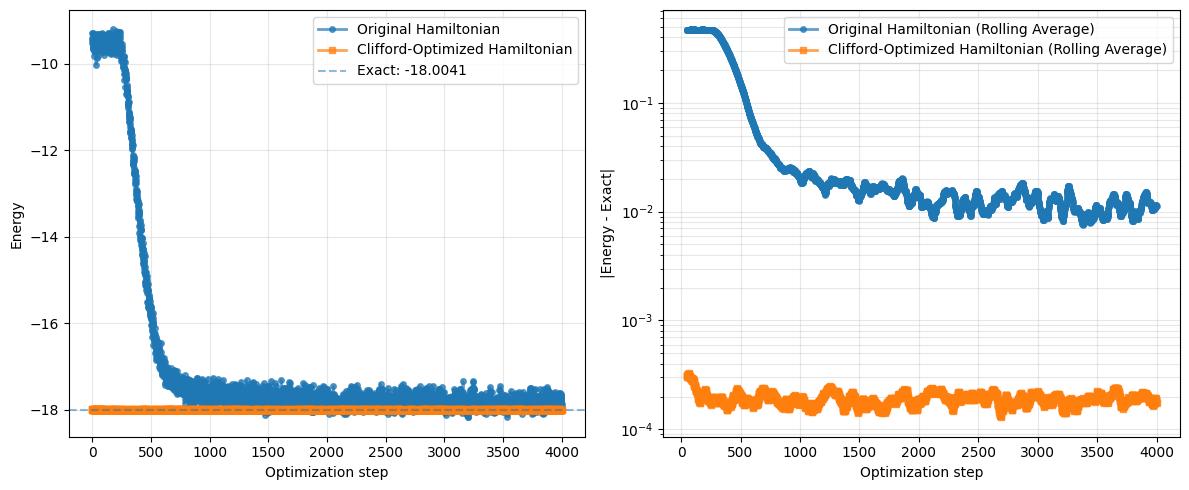

In [28]:
# Plot convergence comparison
plt.figure(figsize=(12, 5))

# Plot 1: Energy vs iteration
plt.subplot(1, 2, 1)
plt.plot(it_orig, E_orig, 'o-', label="Original Hamiltonian", linewidth=2, markersize=4, alpha=0.7)
plt.plot(it_cliff, E_cliff, 's-', label="Clifford-Optimized Hamiltonian", linewidth=2, markersize=4, alpha=0.7)
plt.axhline(exact_orig, ls="--", color="C0", alpha=0.5, label=f"Exact: {exact_orig:.4f}")
if not np.isclose(exact_cliff, exact_orig):
    plt.axhline(exact_cliff, ls="--", color="C1", alpha=0.5, label=f"Exact (Clifford): {exact_cliff:.4f}")
plt.xlabel("Optimization step")
plt.ylabel("Energy")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
def rolling_average(data, window_size):
    """Compute rolling average of the data with specified window size."""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Plot 2: Error vs iteration (log scale)
plt.subplot(1, 2, 2)
if N_sites <= 18:
    error_orig = np.abs((E_orig - exact_orig) / exact_orig)
    error_cliff = np.abs((E_cliff - exact_cliff) / exact_orig)
    label = "|Energy - Exact|"
else:
    e_min = min( min(E_orig), min(E_cliff))
    error_orig = np.abs(E_orig - e_min)  # Use final energy as reference if exact is not available
    error_cliff = np.abs(E_cliff - e_min)
    label = "|Energy - Minimum|"

window_size = 50
# plt.semilogy(it_orig, error_orig, 'o-', label="Original Hamiltonian", linewidth=2, markersize=4, alpha=0.7)
plt.semilogy(it_orig[window_size-1:], rolling_average(error_orig, window_size), 'o-', label="Original Hamiltonian (Rolling Average)", linewidth=2, markersize=4, alpha=0.7)

# plt.semilogy(it_cliff, error_cliff, 's-', label="Clifford-Optimized Hamiltonian", linewidth=2, markersize=4, alpha=0.7)
plt.semilogy(it_cliff[window_size-1:], rolling_average(error_cliff, window_size), 's-', label="Clifford-Optimized Hamiltonian (Rolling Average)", linewidth=2, markersize=4, alpha=0.7)

plt.xlabel("Optimization step")
plt.ylabel(label)
plt.legend(loc='best')
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
# plt.savefig(f"kagome_comparison_N{N_sites}.png", dpi=150, bbox_inches='tight')
plt.show()


In [111]:
# save the log data for further analysis
import json

def save_log_to_json(log, filename, **metadata):
    """Save NetKet RuntimeLog to a JSON file."""
    # datadict = dict(log.data)
    log.serialize(filename)

    with open(filename,'r') as f:
        dic = json.load(f)

        dic.update(metadata)

    with open(filename,'w') as f:
        json.dump(dic, f)

metadata = {
    "N_sites": N_sites,
    "N_Samples": N_Samples,
    "RBMAlpha": RBMAlpha,
    "learning_rate": learning_rate,
    "diag_shift": diag_shift,
    "exact_energy": exact_orig if N_sites <= 18 else None,
}
save_log_to_json(log_original, "logs/toric_code_pert_original.json", **metadata)
save_log_to_json(log_clifford, "logs/toric_code_pert_clifford.json", **metadata)


In [112]:
# Analysis
print("\n" + "="*60)
print("Analysis")
print("="*60)

# Calculate convergence rates
def estimate_convergence_rate(energies, exact):
    errors = np.abs(energies - exact)
    errors = errors[errors > 1e-10]  # Filter out numerical noise
    if len(errors) > 1:
        # Simple exponential fit: error ~ exp(-rate * step)
        steps = np.arange(1, len(errors) + 1)
        log_errors = np.log(errors + 1e-12)
        rate = -np.polyfit(steps, log_errors, 1)[0]
        return rate
    return 0

rate_orig = estimate_convergence_rate(E_orig, exact_orig)
rate_cliff = estimate_convergence_rate(E_cliff, exact_cliff)

print(f"\nEstimated convergence rates (exponential decay):")
print(f"  Original Hamiltonian: {rate_orig:.4f}")
print(f"  Clifford-Optimized:   {rate_cliff:.4f}")
if rate_cliff > rate_orig:
    print(f"  Speedup: {rate_cliff/rate_orig:.2f}x faster convergence with Clifford optimization")
elif rate_orig > 0:
    print(f"  Slowdown: {rate_orig/rate_cliff:.2f}x slower convergence with Clifford optimization")

print(f"\nFinal errors:")
print(f"  Original: {error_orig[-1]:.6f}")
print(f"  Clifford: {error_cliff[-1]:.6f}")
if error_cliff[-1] < error_orig[-1]:
    improvement = (error_orig[-1] - error_cliff[-1]) / error_orig[-1] * 100
    print(f"  Improvement: {improvement:.1f}% lower error with Clifford optimization")


Analysis

Estimated convergence rates (exponential decay):
  Original Hamiltonian: 0.0008
  Clifford-Optimized:   0.0000
  Slowdown: 16.61x slower convergence with Clifford optimization

Final errors:
  Original: 0.010681
  Clifford: 0.000153
  Improvement: 98.6% lower error with Clifford optimization


In [ ]:
import sys
sys.path.append('../..')
from ClusterExpansion import cluster_expansion
from Netket.analysis import infidelity

def get_infidelity_from_coeffs(coeffs, gs, n_coeffs_list):
    infidelities = []
    for n_coeffs in n_coeffs_list:
        coeffs_compressed = np.zeros_like(coeffs)
        # get indices of n_coeffs largest coefficients
        indices = np.argsort(np.abs(coeffs))[::-1][:n_coeffs]
        coeffs_compressed[indices] = coeffs[indices]
        
        # reconstruct the wave function
        psi_reconstructed = cluster_expansion.fwht(coeffs_compressed)
        
        # compute infidelity
        infidelities.append(infidelity(psi_reconstructed, gs))
    return infidelities

if N_sites <= 18:
    # Cluster expansion for original Hamiltonian
    coeffs_orig = cluster_expansion.fwht_coeffs_in_cluster_col_order(np.log(np.abs(gs_orig)), op_kitaev.hilbert)
    
    # Cluster expansion for Clifford-optimized Hamiltonian
    coeffs_cliff = cluster_expansion.fwht_coeffs_in_cluster_col_order(np.log(np.abs(gs_cliff)), op_clifford.hilbert)
    
    n_coeffs_list = np.unique(np.logspace(0, np.log10(len(coeffs_orig)), 100, dtype=int))
    
    infidelities_orig = get_infidelity_from_coeffs(coeffs_orig, gs_orig, n_coeffs_list)
    infidelities_cliff = get_infidelity_from_coeffs(coeffs_cliff, gs_cliff, n_coeffs_list)


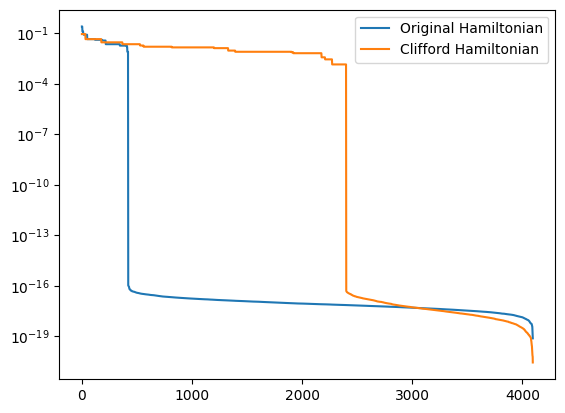

In [38]:
plt.plot(np.sort(np.abs(gs_orig))[::-1], label="Original Hamiltonian")
plt.plot(np.sort(np.abs(gs_cliff))[::-1], label="Clifford Hamiltonian")
plt.yscale('log')
plt.legend()

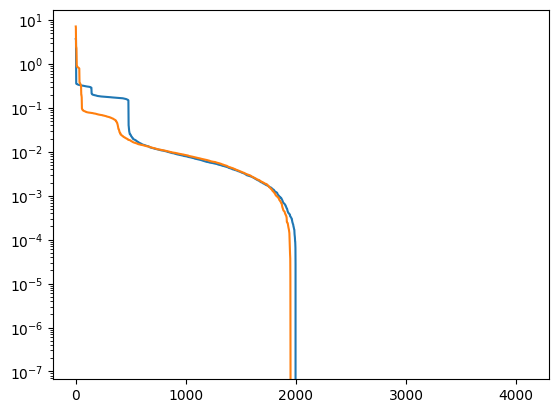

In [41]:
plt.plot(np.sort(coeffs_orig)[::-1])
plt.plot(np.sort(coeffs_cliff)[::-1])
plt.yscale('log')

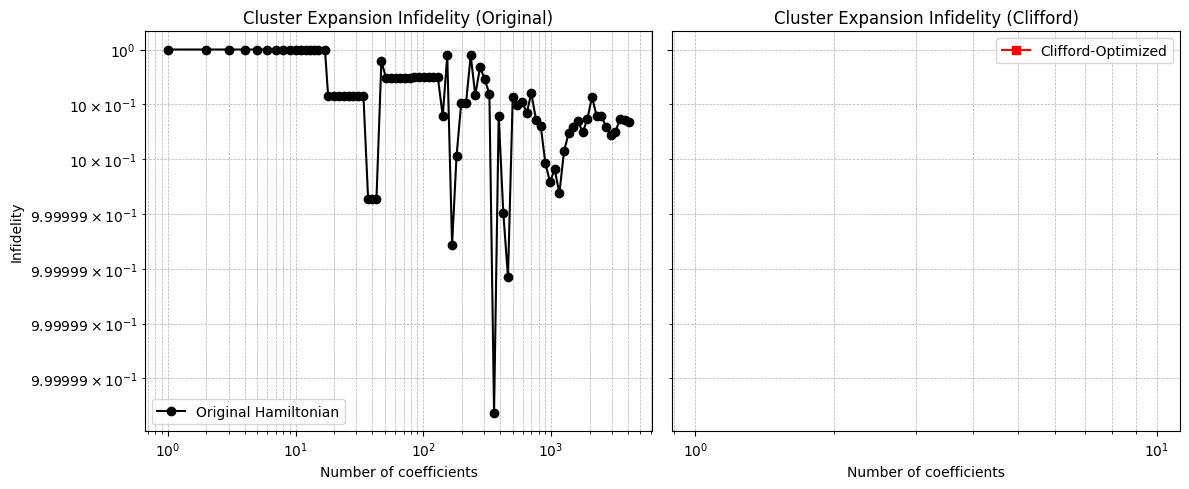

In [23]:
if N_sites <= 18:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Plot for original Hamiltonian
    axes[0].plot(n_coeffs_list, infidelities_orig, 'o-', label='Original Hamiltonian', color='black')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Number of coefficients')
    axes[0].set_ylabel('Infidelity')
    axes[0].set_title('Cluster Expansion Infidelity (Original)')
    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[0].legend()

    # Plot for Clifford-optimized Hamiltonian
    axes[1].plot(n_coeffs_list, infidelities_cliff, 's-', label='Clifford-Optimized', color='red')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('Number of coefficients')
    axes[1].set_title('Cluster Expansion Infidelity (Clifford)')
    axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
